# Day 3: Supervised ML — Classification

<a target="_blank" href="https://colab.research.google.com/github/LuWidme/uk259/blob/rework/demos/06_Classification.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




**Learning Objectives:**
- Understand what classification is and when to use it
- Implement K-Nearest Neighbors (KNN) from scratch and with scikit-learn
- Evaluate classifiers with train/test split, accuracy, and the confusion matrix
- Build and interpret Decision Trees
- Compare classification models and detect overfitting

**Datasets Used:** Synthetic blobs, Iris, Titanic (`datasets/titanic.csv`)

> **Looking for Support Vector Machines (SVM)?** They moved to the optional bonus notebook `demos/advanced/06_5_Support_Vector_Machines.ipynb`.

---


In [ ]:
# === COURSE SETUP — run this cell first! ===
# Installs the required packages (most are preinstalled on Google Colab)
# and downloads the course datasets so the notebook works out of the box.
%pip install -q numpy pandas matplotlib seaborn scikit-learn

import os, urllib.request

DATA_URL = "https://raw.githubusercontent.com/LuWidme/uk259/rework/datasets/"
for folder in ("datasets", os.path.join("..", "datasets")):
    os.makedirs(folder, exist_ok=True)
    for fname in ['titanic.csv', 'melb_data.csv', 'Company_data.csv']:
        path = os.path.join(folder, fname)
        if not os.path.exists(path):
            urllib.request.urlretrieve(DATA_URL + fname, path)

print("Setup complete — you are ready to go!")

## What is Classification?

**Classification** is a type of supervised learning where we predict **discrete class labels** (categories).

**Examples:**
- Email: **spam** or **not spam**
- Medical test: **malignant** or **benign**
- Flower species: **setosa**, **versicolor**, or **virginica**

**How it works:**
1. **Training:** Show the model many labeled examples ("this email is spam")
2. **Learning:** The model finds patterns that separate the classes
3. **Prediction:** Given a new, unseen example, the model assigns it to a class

**Classification vs. Regression:**

| | Classification | Regression |
|---|---|---|
| **Output** | Category (spam/not spam) | Number (price: €250,000) |
| **Examples** | Disease diagnosis, spam filter | House price, temperature |
| **Algorithms** | KNN, SVM, Decision Tree | Linear Regression |

In this notebook, we'll explore **three popular classification algorithms** and learn when to use each.

---

## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


---

## Part 1: K-Nearest Neighbors (KNN)

### How KNN Works

K-Nearest Neighbors is one of the simplest ML algorithms. It classifies a new data point by looking at its **k closest neighbors** and taking a majority vote.

**Analogy:** You move to a new neighborhood. To figure out if you'll like it, you ask the 5 nearest neighbors. If 4 out of 5 love it, you predict you'll love it too!

**Steps:**
1. Calculate the distance from the new point to **all** training points
2. Select the **k** closest neighbors
3. The most common class among those neighbors is the prediction

**Key parameter:** `k` — the number of neighbors to consider (typically odd to avoid ties)

### The Data

We'll start with a simple synthetic dataset of 2D blobs (clusters) so we can easily visualize what's happening.

Training samples: 400
Test samples: 100


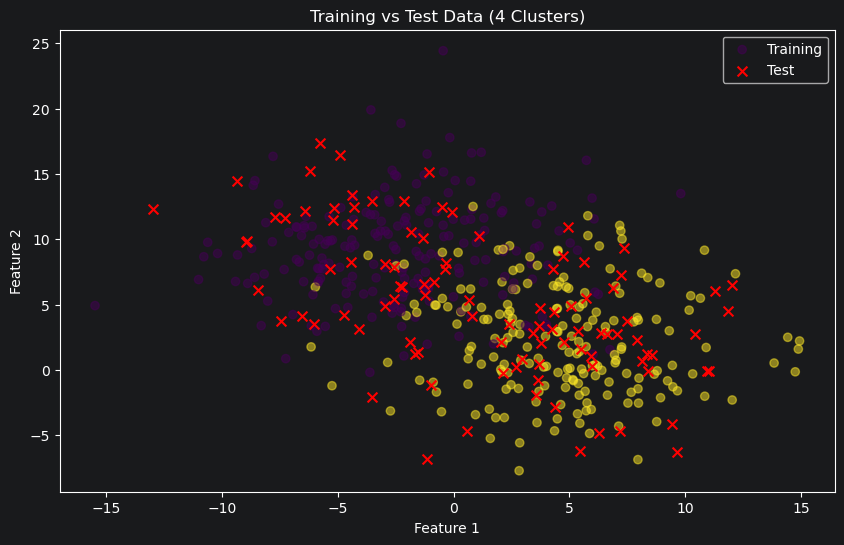

In [9]:
from sklearn.datasets import make_blobs

# Generate 4 clusters of points
data, labels = make_blobs(n_samples=500, centers=2, cluster_std=4, random_state=42)

# Split into training and test data
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.20, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, marker='o', alpha=0.5,
            cmap='viridis', label='Training')
plt.scatter(X_test[:, 0], X_test[:, 1], c='red', marker='x', s=50, label='Test')
plt.legend()
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training vs Test Data (4 Clusters)')
plt.show()

### Task 1: Implement KNN from Scratch

Implement the K-Nearest Neighbor algorithm step by step.

**Hints:**
- Euclidean distance: `np.sqrt(np.sum((a - b)**2, axis=1))`
- Indices of smallest values: `np.argsort(array)[:k]`
- Most common label: `np.bincount(labels).argmax()`

In [ ]:
def knn_predict(new_point, experience_data, experience_labels, k):
    """
    Predict the class of new_point using K-Nearest Neighbors.
    
    Parameters:
        new_point: array of shape (n_features,) - the point to classify
        experience_data: array of shape (n_samples, n_features) - training data
        experience_labels: array of shape (n_samples,) - training labels
        k: int - number of neighbors to consider
    
    Returns:
        predicted_class: int - the predicted class label
    """
    
    # Step 1: Calculate Euclidean distance to all training points
    distances = None  # TODO: np.sqrt(np.sum((experience_data - new_point)**2, axis=1))
    
    # Step 2: Find the indices of the k smallest distances
    k_nearest_indices = None  # TODO: np.argsort(distances)[:k]
    
    # Step 3: Get the labels of those k nearest neighbors
    k_nearest_labels = None  # TODO: experience_labels[k_nearest_indices]
    
    # Step 4: Return the most common label (majority vote)
    predicted_class = None  # TODO: np.bincount(k_nearest_labels).argmax()
    
    return predicted_class

In [ ]:
# Test your KNN implementation
k = 5

print(f"Testing KNN implementation (k={k}):")
print(f"{'Point':<8} {'Predicted':<12} {'Actual':<10} {'Match'}")
print("-" * 40)

correct = 0
for i in range(10):
    prediction = knn_predict(X_test[i], X_train, y_train, k)
    actual = y_test[i]
    match = '✓' if prediction == actual else '✗'
    if prediction == actual:
        correct += 1
    print(f"{i:<8} {prediction:<12} {actual:<10} {match}")

print(f"\nAccuracy on sample: {correct}/10 ({correct/10:.0%})")

### Using Scikit-Learn's KNN

Implementing from scratch helps understanding, but in practice we use optimized libraries.

Scikit-learn's `KNeighborsClassifier` is:
- Much faster (uses efficient data structures like KD-trees)
- Supports different distance metrics
- Has a consistent API shared with all other sklearn models

In [10]:
from sklearn.neighbors import KNeighborsClassifier

# Create, train, and evaluate
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {accuracy:.4f}")
print(f"Correctly classified: {sum(y_pred_knn == y_test)} / {len(y_test)}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.9200
Correctly classified: 92 / 100

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.91        45
           1       0.96      0.89      0.92        55

    accuracy                           0.92       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.92      0.92      0.92       100



### Visualizing KNN Decision Boundaries

A decision boundary shows **where** the model switches from predicting one class to another. This helps us understand how the model "sees" the data.

In [ ]:
# Create a mesh grid covering the feature space
h = 0.1
x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict for every point in the grid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, marker='o',
            s=50, edgecolors='k', cmap='viridis', alpha=0.7, label='Training')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='s',
            s=80, edgecolors='red', cmap='viridis', label='Test')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'KNN Decision Boundaries (k={knn.n_neighbors})')
plt.legend()
plt.show()

---

## Part 2: Evaluating a Classifier

Before trusting a model, we need to measure how well it performs. Three tools do most of the work.

### 1. Train/Test Split

We never judge a model on the data it learned from — that would be like giving students the exam answers in advance. Instead we **split** the data:
- **Training set** (~75–80%): the model learns from this
- **Test set** (~20–25%): kept hidden during training, used only to measure performance on *unseen* data

This is why we used `train_test_split` earlier. A model that scores high on training data but low on test data is **overfitting**.

### 2. Accuracy

The simplest score — the fraction of predictions that are correct:

```
accuracy = correct predictions / total predictions
```

Accuracy is intuitive, but it can mislead when classes are imbalanced (if 99% of emails are *not* spam, always guessing "not spam" gives 99% accuracy while catching zero spam). That's why we also look at the confusion matrix.

### 3. Confusion Matrix

A confusion matrix shows **exactly which classes get confused with which**. Each row is the true class, each column is the predicted class:
- **Diagonal** = correct predictions
- **Off-diagonal** = mistakes (and which class they were mistaken for)

Let's visualize the confusion matrix for our KNN model.

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Accuracy of the KNN model from Part 1
acc = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy: {acc:.2%}")

# Visualize the confusion matrix as a heatmap
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix — KNN on the 4-cluster data')
plt.show()

print("Diagonal = correct predictions.")
print("Off-diagonal cells show where the model confused one class for another.")

### Precision and Recall (briefly)

Two refinements of accuracy that the `classification_report` prints for each class:
- **Precision** — of all the points the model labeled as class X, how many really were class X? (Avoids false alarms.)
- **Recall** — of all the actual class-X points, how many did the model find? (Avoids misses.)
- **F1-score** — a single number balancing the two.

For example, a medical test wants **high recall** (don't miss sick patients), even at the cost of a few false alarms.

---

## Part 3: Decision Trees

### How Decision Trees Work

Decision Trees classify data by asking a series of **yes/no questions** about the features.

**Analogy:** It's like playing 20 Questions. The tree asks: "Is flipper length > 206mm?" If yes, go left. If no, go right. Keep asking until you reach a final answer.

**Structure:**
- **Root node:** First question (best feature to split on)
- **Internal nodes:** Follow-up questions
- **Leaf nodes:** Final predictions (class labels)

**Key advantage:** Decision Trees are **easy to interpret** — you can trace exactly why a prediction was made!

**Key parameters:**
- `max_depth`: How deep the tree can grow (controls overfitting)
- `criterion`: How to measure split quality (`'gini'` or `'entropy'`)

### Example: Iris Classification

The **Iris dataset** is a classic ML dataset with measurements of 150 iris flowers from 3 species.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

print(f"Features: {iris.feature_names}")
print(f"Classes: {list(iris.target_names)}")
print(f"Samples: {len(X_iris)}")

iris_df = pd.DataFrame(X_iris, columns=iris.feature_names)
iris_df['species'] = [iris.target_names[i] for i in y_iris]
iris_df.head()

In [ ]:
# Split the data
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

# Train a Decision Tree
dt_clf = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
dt_clf.fit(X_train_iris, y_train_iris)

# Evaluate
y_pred_dt = dt_clf.predict(X_test_iris)

print(f"Training accuracy: {dt_clf.score(X_train_iris, y_train_iris):.4f}")
print(f"Test accuracy:     {dt_clf.score(X_test_iris, y_test_iris):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_iris, y_pred_dt, target_names=iris.target_names))

### Visualizing the Decision Tree

One of the biggest advantages of decision trees: you can **see** exactly how the model makes decisions.

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_clf,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree for Iris Classification", fontsize=16)
plt.show()

print("Reading the tree:")
print("- Each box shows: the question (top), sample count, and predicted class")
print("- Left branch = True (condition met), Right branch = False")
print("- Colors indicate the predicted class")

### Feature Importance

Decision trees can tell us which features are **most useful** for making predictions.

In [ ]:
importances = dt_clf.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Feature Importances:")
print(feat_imp.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue', edgecolor='black')
plt.xlabel('Importance')
plt.title('Feature Importance in Decision Tree')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Understanding Overfitting in Decision Trees

**Overfitting** happens when a model learns the training data "too well" — including noise. It performs great on training data but poorly on new data.

Decision trees are **especially prone to overfitting** when they grow too deep. Let's see this in action.

In [ ]:
depths = [1, 2, 3, 5, 10, None]  # None = unlimited depth
train_scores = []
test_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_iris, y_train_iris)
    
    train_acc = dt.score(X_train_iris, y_train_iris)
    test_acc = dt.score(X_test_iris, y_test_iris)
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    
    depth_str = str(depth) if depth is not None else 'None'
    gap = train_acc - test_acc
    print(f"Depth={depth_str:>4s}:  Train={train_acc:.4f}  Test={test_acc:.4f}  Gap={gap:.4f}")

# Visualize
plt.figure(figsize=(10, 6))
x_labels = [str(d) if d is not None else 'None' for d in depths]
plt.plot(x_labels, train_scores, 'o-', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(x_labels, test_scores, 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Overfitting: Training vs Test Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nKey insight: When the gap between train and test accuracy grows,")
print("the model is overfitting — memorizing training data instead of learning patterns.")

---

## Part 4: Model Comparison

Now let's compare our two core algorithms — **KNN** and **Decision Tree** — side-by-side on the same dataset (Iris), using the evaluation metrics from Part 2.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_iris, y_train_iris)
    y_pred = model.predict(X_test_iris)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_iris, y_pred),
        'Precision': precision_score(y_test_iris, y_pred, average='weighted'),
        'Recall': recall_score(y_test_iris, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test_iris, y_pred, average='weighted')
    })

comparison_df = pd.DataFrame(results).round(4)
print("Model Comparison on Iris Dataset:")
print(comparison_df.to_string(index=False))

In [ ]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(comparison_df))
width = 0.2

for i, metric in enumerate(metrics):
    offset = width * (i - 1.5)
    ax.bar(x + offset, comparison_df[metric], width, label=metric)

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Classification Metrics')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=30, ha='right')
ax.legend()
ax.set_ylim([0.8, 1.02])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### When to Use Which Algorithm?

| Algorithm | Best For | Pros | Cons |
|-----------|----------|------|------|
| **KNN** | Small datasets, simple problems | Simple, no training step | Slow predictions, sensitive to feature scale |
| **Decision Tree** | When interpretability matters | Easy to understand, handles mixed data | Prone to overfitting |

**General advice:**
1. Start simple (Decision Tree or KNN)
2. Try multiple models and compare
3. Always validate on test data
4. **Scale your features** for distance-based methods like KNN (use `StandardScaler`)

> **Bonus:** A third popular algorithm, **Support Vector Machines (SVM)**, is covered in `demos/advanced/06_5_Support_Vector_Machines.ipynb`.

---

## Part 5: Exercises

### Exercise 1: Titanic Survival Prediction

**Scenario:** Predict which passengers survived the Titanic disaster based on their characteristics.

**Tasks:**
1. Load the Titanic dataset
2. Preprocess the data (handle missing values, encode categorical features)
3. Train both classifiers (KNN and Decision Tree)
4. Evaluate each with accuracy and a confusion matrix, and compare their performance

**Hints:**
- Use `pd.get_dummies()` to encode categorical columns like 'Sex'
- Drop columns with too many missing values (e.g., 'Cabin')
- Fill remaining missing values with the median: `df.fillna(df.median())`
- Use `StandardScaler` before KNN (distance-based)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Step 1: Load the Titanic dataset
titanic = pd.read_csv('../datasets/titanic.csv')
print(f"Dataset shape: {titanic.shape}")
print(f"\nColumns: {list(titanic.columns)}")
print(f"\nMissing values:")
print(titanic.isnull().sum())
titanic.head()

In [ ]:
# Step 2: Preprocess the data

# TODO: Select useful features and the target variable 'Survived'
# Suggested features: 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare'
features = None  # TODO: list of feature column names

# TODO: Create a working copy with only the needed columns
df = None  # TODO: titanic[features + ['Survived']].copy()

# TODO: Handle missing values
# Hint: df['Age'].fillna(df['Age'].median(), inplace=True)

# TODO: Encode categorical variables
# Hint: df = pd.get_dummies(df, columns=['Sex'], drop_first=True)

# TODO: Define X (features) and y (target)
X_titanic = None  # TODO: all columns except 'Survived'
y_titanic = None  # TODO: the 'Survived' column

# TODO: Split into train/test
# Hint: train_test_split(X_titanic, y_titanic, test_size=0.25, random_state=42, stratify=y_titanic)

In [ ]:
# Step 3 & 4: Train models and compare

# TODO: Scale features (important for KNN!)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_t)
# X_test_scaled = scaler.transform(X_test_t)

# TODO: Train KNN and a Decision Tree on the Titanic data
# TODO: Print accuracy and the confusion matrix for each
# TODO: Which model performs best? Why?

---

### Exercise 2: KNN Parameter Tuning

**Task:** Explore how the number of neighbors `k` affects KNN performance on the Iris dataset.

1. Try k values from 1 to 15
2. Record training and test accuracy for each
3. Plot the results
4. Which `k` gives the best test accuracy?

In [ ]:
# TODO: Try different k values for KNN
k_values = range(1, 16)
train_accuracies = None  # TODO: list of training accuracies for each k
test_accuracies = None   # TODO: list of test accuracies for each k

# TODO: Loop over k_values
# For each k:
#   1. Create KNeighborsClassifier(n_neighbors=k)
#   2. Fit on X_train_iris, y_train_iris
#   3. Record training and test accuracy

# TODO: Plot training vs test accuracy for each k
# TODO: Print the best k value

## Summary

In this notebook you learned:

✓ What classification is and how it differs from regression  
✓ How K-Nearest Neighbors works (and how to implement it from scratch)  
✓ How to evaluate classifiers with train/test split, accuracy, and the confusion matrix  
✓ How Decision Trees make interpretable classification decisions  
✓ How to compare multiple models and choose the best one  
✓ The concept of overfitting and how to detect it  

### Key Takeaways

1. **No single best algorithm** — always try multiple models
2. **Evaluate on test data** — training accuracy alone is misleading
3. **Read the confusion matrix** — accuracy alone can hide which classes get confused
4. **Scale your features** for distance-based methods (KNN)
5. **Watch for overfitting** — compare train vs. test performance

### What's Next?

- **Linear Regression:** Predicting continuous values instead of categories
- **Support Vector Machines (SVM):** Optional bonus notebook `demos/advanced/06_5_Support_Vector_Machines.ipynb`
- **Ensemble methods:** Random Forests combine many Decision Trees
- **Neural Networks:** Deep learning for complex classification tasks

---